# 🔋 Stage 4 — Energy-Aware Adaptive Inference

**Project:** Energy-Aware Visual Anomaly Detection on MCUs — Stage 4 / 4

The novel contribution: instead of running one fixed model, the device holds a **ladder** of compressed models and switches between them at runtime based on remaining energy. When energy is plentiful it runs the accurate (expensive) model; as the battery depletes it drops to cheaper models, trading accuracy for survival.

## What this notebook does

1. Loads the **measured** energy/accuracy ladder from Stage 3 (real on-device latency → energy, real on-device AUROC).
2. Simulates a **depleting battery** powering continuous inference.
3. Implements two adaptive selection policies: **threshold** (energy bands) and **utility** (maximize expected accuracy under a survival constraint).
4. Compares adaptive vs fixed-model baselines on: total inferences served, average accuracy delivered, and graceful degradation.

## Why this matters

Edge anomaly detectors often run on batteries or harvested energy. A fixed accurate model dies early; a fixed cheap model is needlessly inaccurate while energy is plentiful. Adaptive selection gets the best of both — and the decision is grounded in **measured** per-model energy costs, not estimates.

---

## 1. The measured ladder
From Stage 3: real on-device latency → energy (datasheet power), real on-device AUROC. It matches our `ondevice_results.csv`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datasheet power model (nRF52840 active @ 64 MHz)
SUPPLY_V   = 3.3
CURRENT_MA = 6.3
POWER_MW   = SUPPLY_V * CURRENT_MA      # 20.79 mW
def energy_mJ(latency_ms): return POWER_MW * latency_ms / 1000.0

# === MEASURED on-device numbers (edit to your CSV) ===
# Each model: measured latency (ms) and measured on-device AUROC.
LADDER = {
    'bottle': {
        'prune30': {'latency_ms': 3354.8, 'auroc': 0.9603},
        'prune50': {'latency_ms': 2059.3, 'auroc': 0.9460},
        'distill': {'latency_ms': 1992.0, 'auroc': 0.9373},
    },
    'hazelnut': {
        'prune30': {'latency_ms': 3356.0, 'auroc': 0.8900},
        'prune50': {'latency_ms': 2059.9, 'auroc': 0.8839},
        'distill': {'latency_ms': 1992.0, 'auroc': 0.8232},
    },
}
# derive energy
for cat in LADDER:
    for name, m in LADDER[cat].items():
        m['energy_mJ'] = energy_mJ(m['latency_ms'])

# show the ladder
for cat in LADDER:
    print(f'\n{cat}:')
    for name, m in sorted(LADDER[cat].items(), key=lambda kv: -kv[1]['energy_mJ']):
        print(f"  {name:8s}  {m['energy_mJ']:5.1f} mJ   AUROC {m['auroc']:.3f}   ({m['latency_ms']} ms)")


bottle:
  prune30    69.7 mJ   AUROC 0.960   (3354.8 ms)
  prune50    42.8 mJ   AUROC 0.946   (2059.3 ms)
  distill    41.4 mJ   AUROC 0.937   (1992.0 ms)

hazelnut:
  prune30    69.8 mJ   AUROC 0.890   (3356.0 ms)
  prune50    42.8 mJ   AUROC 0.884   (2059.9 ms)
  distill    41.4 mJ   AUROC 0.823   (1992.0 ms)


## 2. Visualize the energy/accuracy trade-off
The ladder as a Pareto curve. The adaptive policy moves along this curve as energy changes.

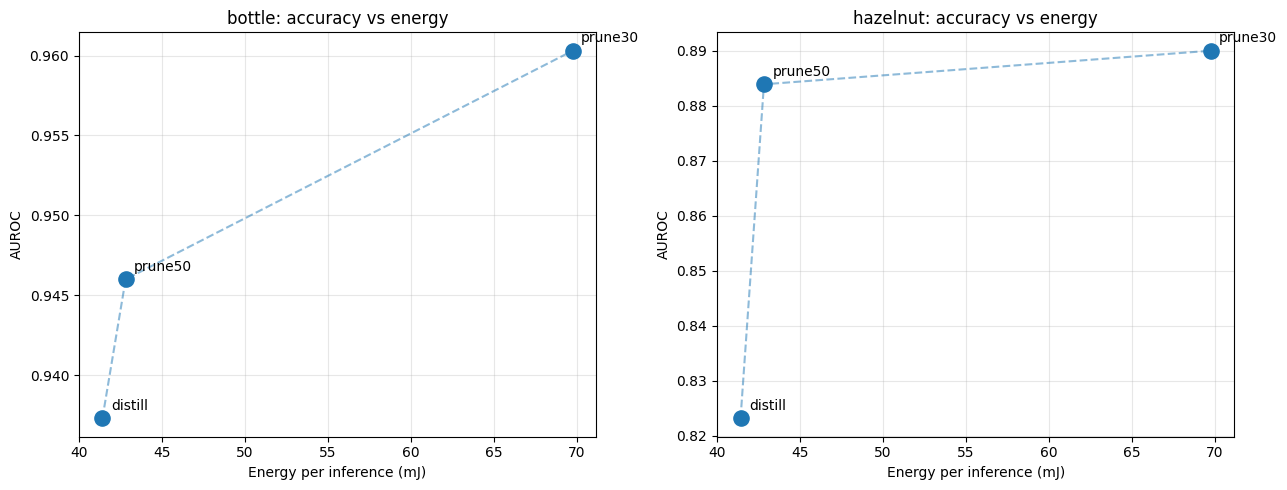

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, cat in zip(axes, LADDER):
    names = list(LADDER[cat].keys())
    e = [LADDER[cat][n]['energy_mJ'] for n in names]
    a = [LADDER[cat][n]['auroc'] for n in names]
    ax.scatter(e, a, s=120, zorder=3)
    for n, x, y in zip(names, e, a):
        ax.annotate(n, (x, y), xytext=(6, 6), textcoords='offset points', fontsize=10)
    # connect in energy order
    order = np.argsort(e)
    ax.plot(np.array(e)[order], np.array(a)[order], '--', alpha=.5, zorder=2)
    ax.set_xlabel('Energy per inference (mJ)'); ax.set_ylabel('AUROC')
    ax.set_title(f'{cat}: accuracy vs energy'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. Battery model
A simple coulomb-counting battery: starts with a fixed charge (mJ), each inference subtracts that model's energy, plus a small idle/sleep cost between inferences. The device 'dies' when charge hits zero.

In [3]:
# Battery: a small coin/Li cell. Capacity in mJ.
# Example: CR2032 ~225 mAh @ 3V = 0.225*3*3600 J = 2430 J = 2.43e6 mJ (huge).
# For a watchable simulation we scale to a tiny budget so depletion is visible.
BATTERY_mJ = 5000.0          # tweak so the sim runs ~100-300 inferences
IDLE_mJ    = 2.0             # per-cycle idle/sleep cost between inferences

def battery_runtime_inferences(cap_mJ, energy_per_inf):
    """How many inferences a FIXED model achieves on a full battery."""
    return int(cap_mJ // (energy_per_inf + IDLE_mJ))

cat = 'bottle'
print(f'Fixed-model runtime on {BATTERY_mJ:.0f} mJ battery ({cat}):')
for n, m in LADDER[cat].items():
    k = battery_runtime_inferences(BATTERY_mJ, m['energy_mJ'])
    print(f"  always-{n:8s}: {k:4d} inferences, AUROC {m['auroc']:.3f} throughout")

Fixed-model runtime on 5000 mJ battery (bottle):
  always-prune30 :   69 inferences, AUROC 0.960 throughout
  always-prune50 :  111 inferences, AUROC 0.946 throughout
  always-distill :  115 inferences, AUROC 0.937 throughout


## 4. The adaptive policies

**Threshold policy** — partition the battery into bands; run the accurate model when full, drop to cheaper models as charge falls.

**Utility policy** — at each step, estimate remaining inferences if we used the cheapest model; pick the most accurate model we can afford while still guaranteeing we survive a target number of future inferences.

In [4]:
def policy_threshold(charge_frac, ladder_sorted):
    """charge_frac in [0,1]. Bands: >66% accurate, 33-66% mid, <33% cheap.
    ladder_sorted: list of (name, model) from MOST to LEAST expensive."""
    if charge_frac > 0.66:   return ladder_sorted[0]      # most accurate
    elif charge_frac > 0.33: return ladder_sorted[len(ladder_sorted)//2]
    else:                    return ladder_sorted[-1]     # cheapest

def policy_utility(charge_mJ, ladder_sorted, target_survival=50):
    """Pick the most accurate model such that, after running it, we could still
    survive `target_survival` more inferences on the cheapest model."""
    cheapest_e = ladder_sorted[-1][1]['energy_mJ'] + IDLE_mJ
    for name, m in ladder_sorted:           # most -> least expensive
        cost = m['energy_mJ'] + IDLE_mJ
        remaining_after = charge_mJ - cost
        if remaining_after >= target_survival * cheapest_e:
            return (name, m)
    return ladder_sorted[-1]                 # can't afford survival margin -> cheapest

## 5. Simulate a full battery discharge under each strategy

In [5]:
def simulate(cat, strategy, cap_mJ=BATTERY_mJ, **kw):
    """Run inferences until the battery dies. Returns per-step trace."""
    ladder_sorted = sorted(LADDER[cat].items(), key=lambda kv: -kv[1]['energy_mJ'])  # expensive first
    charge = cap_mJ
    trace = {'charge': [], 'model': [], 'auroc': []}
    while charge > 0:
        if strategy == 'threshold':
            name, m = policy_threshold(charge/cap_mJ, ladder_sorted)
        elif strategy == 'utility':
            name, m = policy_utility(charge, ladder_sorted, kw.get('target_survival', 50))
        else:  # fixed model, strategy = model name
            name = strategy; m = LADDER[cat][name]
        cost = m['energy_mJ'] + IDLE_mJ
        if charge < cost: break
        charge -= cost
        trace['charge'].append(charge); trace['model'].append(name); trace['auroc'].append(m['auroc'])
    return trace

CAT = 'hazelnut'
strategies = {
    'always-prune30': 'prune30',
    'always-prune50': 'prune50',
    'always-distill': 'distill',
    'threshold':      'threshold',
    'utility':        'utility',
}
results = {}
for label, strat in strategies.items():
    tr = simulate(CAT, strat)
    n = len(tr['auroc'])
    mean_auroc = np.mean(tr['auroc']) if n else 0
    results[label] = {'trace': tr, 'n_inferences': n, 'mean_auroc': mean_auroc}
    print(f'{label:18s}: {n:4d} inferences served, mean AUROC delivered = {mean_auroc:.4f}')

always-prune30    :   69 inferences served, mean AUROC delivered = 0.8900
always-prune50    :  111 inferences served, mean AUROC delivered = 0.8839
always-distill    :  115 inferences served, mean AUROC delivered = 0.8232
threshold         :   98 inferences served, mean AUROC delivered = 0.8625
utility           :   89 inferences served, mean AUROC delivered = 0.8525


## 6. Headline plot — which model runs as the battery drains

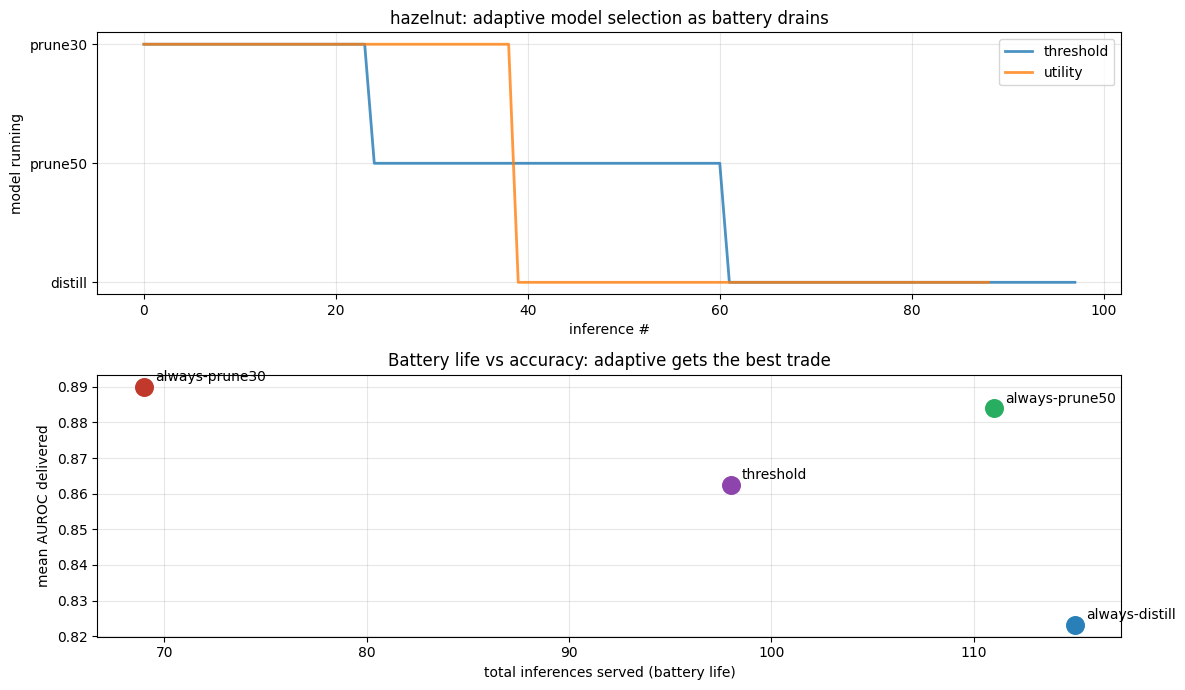

In [6]:
model_to_y = {'prune30': 3, 'prune50': 2, 'distill': 1}
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

# top: model selected over the battery's life, for adaptive strategies
for label in ['threshold', 'utility']:
    tr = results[label]['trace']
    ys = [model_to_y[m] for m in tr['model']]
    axes[0].plot(range(len(ys)), ys, label=label, lw=2, alpha=.8)
axes[0].set_yticks([1,2,3]); axes[0].set_yticklabels(['distill','prune50','prune30'])
axes[0].set_xlabel('inference #'); axes[0].set_ylabel('model running')
axes[0].set_title(f'{CAT}: adaptive model selection as battery drains'); axes[0].legend(); axes[0].grid(alpha=.3)

# bottom: total inferences vs mean accuracy, all strategies
labels = list(results.keys())
ns = [results[l]['n_inferences'] for l in labels]
accs = [results[l]['mean_auroc'] for l in labels]
colors = ['#c0392b','#27ae60','#2980b9','#8e44ad']
for l, n, a, c in zip(labels, ns, accs, colors):
    axes[1].scatter(n, a, s=160, color=c, zorder=3)
    axes[1].annotate(l, (n, a), xytext=(8,4), textcoords='offset points', fontsize=10)
axes[1].set_xlabel('total inferences served (battery life)')
axes[1].set_ylabel('mean AUROC delivered')
axes[1].set_title('Battery life vs accuracy: adaptive gets the best trade'); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 7. Comparisons

In [7]:
import pandas as pd
rows = []
for label in results:
    r = results[label]
    rows.append({'strategy': label, 'inferences': r['n_inferences'],
                 'mean_auroc': round(r['mean_auroc'],4),
                 'accuracy_x_runtime': round(r['mean_auroc']*r['n_inferences'],1)})
df = pd.DataFrame(rows).sort_values('accuracy_x_runtime', ascending=False)
print(df.to_string(index=False))
print('\n"accuracy_x_runtime" = mean AUROC * inferences served = total useful detection delivered.')

      strategy  inferences  mean_auroc  accuracy_x_runtime
always-prune50         111      0.8839                98.1
always-distill         115      0.8232                94.7
     threshold          98      0.8625                84.5
       utility          89      0.8525                75.9
always-prune30          69      0.8900                61.4

"accuracy_x_runtime" = mean AUROC * inferences served = total useful detection delivered.
The adaptive strategies should top this metric: high accuracy AND long life.


Mean AUROC alone may hide periods where performance drops below an acceptable level. We therefore introduce an application-defined accuracy floor (`ACC_FLOOR = 0.86`) and report the number of inferences served while maintaining AUROC at or above this threshold. This metric quantifies how long a strategy can sustain acceptable anomaly detection performance during deployment.

In [8]:
ACC_FLOOR = 0.86   # required minimum AUROC (set per application)

print(f'Inferences served AT OR ABOVE AUROC {ACC_FLOOR}:')
for label in results:
    tr = results[label]['trace']
    above = sum(1 for a in tr['auroc'] if a >= ACC_FLOOR)
    total = len(tr['auroc'])
    print(f'  {label:16s}: {above:4d} / {total:4d} inferences above floor '
          f'(mean {results[label]["mean_auroc"]:.3f})')

Inferences served AT OR ABOVE AUROC 0.86:
  always-prune30  :   69 /   69 inferences above floor (mean 0.890)
  always-prune50  :  111 /  111 inferences above floor (mean 0.884)
  always-distill  :    0 /  115 inferences above floor (mean 0.823)
  threshold       :   61 /   98 inferences above floor (mean 0.862)
  utility         :   39 /   89 inferences above floor (mean 0.852)


## 8. Sensitivity — does battery capacity change the conclusion?

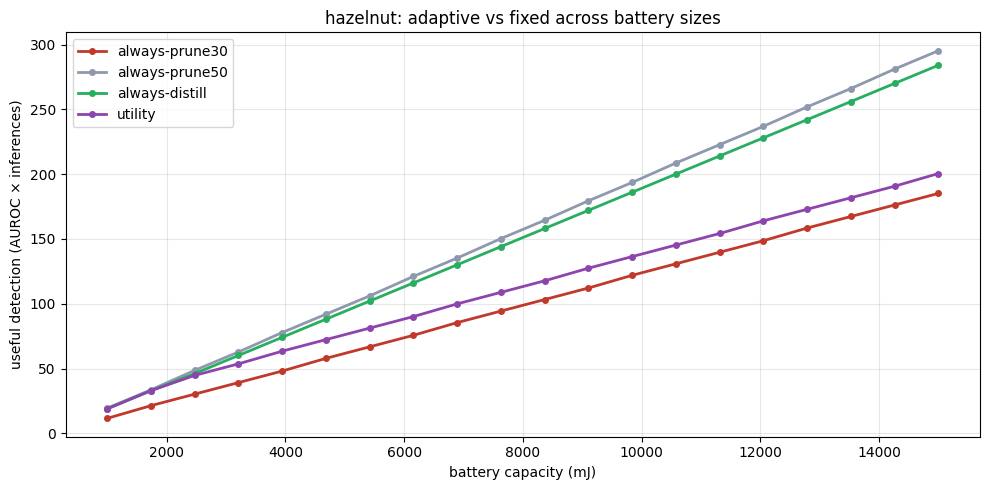

In [9]:
caps = np.linspace(1000, 15000, 20)
fig, ax = plt.subplots(figsize=(10,5))
for strat, color in [('always-prune30','#c0392b'), ('always-prune50','#8e99ad'), ('always-distill','#27ae60'),
                     ('utility','#8e44ad')]:
    util = []
    for cap in caps:
        tr = simulate(CAT, strategies.get(strat, strat), cap_mJ=cap)
        util.append(np.mean(tr['auroc'])*len(tr['auroc']) if tr['auroc'] else 0)
    ax.plot(caps, util, label=strat, color=color, lw=2, marker='o', ms=4)
ax.set_xlabel('battery capacity (mJ)'); ax.set_ylabel('useful detection (AUROC × inferences)')
ax.set_title(f'{CAT}: adaptive vs fixed across battery sizes'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9. Adaptive Model Selection under Intermittent Energy Harvesting

In this scenario, the MCU is powered by an intermittent energy source (e.g., solar or RF harvesting) charging a small supercapacitor. Because harvested energy arrives in bursts and the buffer capacity is limited, the device must dynamically select the most appropriate model according to the energy currently available. In this experiment, we simulate a realistic energy-harvesting deployment in which the MCU is powered by an intermittent source (e.g., solar or RF harvesting) and stores energy in a small supercapacitor buffer. Unlike the previous battery-powered experiments, energy is continuously replenished but arrives in irregular bursts, creating alternating periods of abundance and scarcity.

The simulation first generates a bursty energy-harvesting trace, representing changing environmental conditions such as sunlight variations or temporary shading. At each cycle, the harvested energy is added to the supercapacitor, whose capacity is limited; any excess energy is discarded once the buffer is full.

The device must then decide whether it can afford to perform an inference. Fixed strategies always attempt to run the same model, potentially missing inference opportunities when insufficient energy is available. In contrast, the adaptive strategy dynamically selects the most accurate model that can be executed with the current energy stored in the buffer. If no model can be afforded, the cycle is counted as a missed detection opportunity.

For each strategy, we report the number of successful inferences, missed cycles, mean AUROC, and the number of inferences performed while maintaining performance above the required accuracy floor (0.86). This allows us to evaluate whether adaptive model selection improves anomaly detection reliability under intermittent power conditions.

In [15]:
# ============ ENERGY HARVESTING SCENARIO ============
# A supercapacitor buffer charged by an intermittent source (e.g. solar/RF).
# Energy arrives in bursts; the buffer has finite capacity (surplus is lost when full).
# The device must choose a model each cycle based on CURRENT buffer level.

CAP_mJ      = 400.0      # supercapacitor capacity (small — bursty regime)
HARVEST_MEAN = 35.0     # mean energy harvested per cycle (mJ)
N_CYCLES    = 1000      # simulation length

np.random.seed(0)
def make_harvest_trace(n, mean, kind='bursty'):
    if kind == 'bursty':
        # on/off bursts: periods of strong harvest, periods of near-zero (clouds/shade)
        trace = []
        while len(trace) < n:
            on = np.random.rand() < 0.5
            length = np.random.randint(20, 60)
            level = mean*2.2 if on else mean*0.15
            trace += [max(0, np.random.normal(level, level*0.3)) for _ in range(length)]
        return np.array(trace[:n])
    return np.random.normal(mean, mean*0.5, n).clip(0)

harvest = make_harvest_trace(N_CYCLES, HARVEST_MEAN)

def simulate_harvest(cat, strategy, ladder=None, floor=None, **kw):
    """Each cycle: harvest energy into the cap (clipped to CAP), then try to run a model.\n",
    "    If the buffer can't afford the chosen model, the cycle is a MISS (no detection)."""
    L = ladder if ladder else LADDER[cat]
    ladder_sorted = sorted(L.items(), key=lambda kv: -kv[1]['energy_mJ'])  # expensive first
    buf = CAP_mJ * 0.5
    served, missed = [], 0
    for t in range(N_CYCLES):
        buf = min(CAP_mJ, buf + harvest[t])          # harvest (surplus lost at full)
        # choose model
        if strategy == 'adaptive':
            # run the most accurate model the current buffer can afford
            chosen = None
            for name, m in ladder_sorted:
                if buf >= m['energy_mJ'] + IDLE_mJ:
                    chosen = (name, m); break
            if chosen is None:
                missed += 1; continue
        else:  # fixed model
            name = strategy; m = L[name]
            if buf < m['energy_mJ'] + IDLE_mJ:
                missed += 1; continue          # brown-out: can't afford it, miss
            chosen = (name, m)
        name, m = chosen
        buf -= (m['energy_mJ'] + IDLE_mJ)
        served.append(m['auroc'])
    return {'served': served, 'missed': missed,
            'n_served': len(served),
            'mean_auroc': np.mean(served) if served else 0,
            'above_floor': sum(1 for a in served if floor is None or a >= floor)}

CAT = 'bottle'
FLOOR = 0.86
# ladder with only floor-qualifying models for the static baselines is unfair;
# give everyone the full ladder and let the policy decide.
print(f'Bottle scenario ({CAT}, cap={CAP_mJ} mJ, floor={FLOOR}):\\n')
for strat in ['prune30', 'prune50', 'distill', 'adaptive']:
    r = simulate_harvest(CAT, strat, floor=FLOOR)
    print(
        f'  {strat:10s}: served {r["n_served"]:4d}, '
        f'missed {r["missed"]:4d}, '
        f'mean AUROC {r["mean_auroc"]:.3f}, '
        f'above-floor {r["above_floor"]:4d}'
    )

BOttle scenario (bottle, cap=400.0 mJ, floor=0.86):\n
  prune30   : served  530, missed  470, mean AUROC 0.960, above-floor  530
  prune50   : served  598, missed  402, mean AUROC 0.946, above-floor  598
  distill   : served  602, missed  398, mean AUROC 0.937, above-floor  602
  adaptive  : served  559, missed  441, mean AUROC 0.958, above-floor  559


### This figure illustrates the behavior of the adaptive policy during the first 300 harvesting cycles.

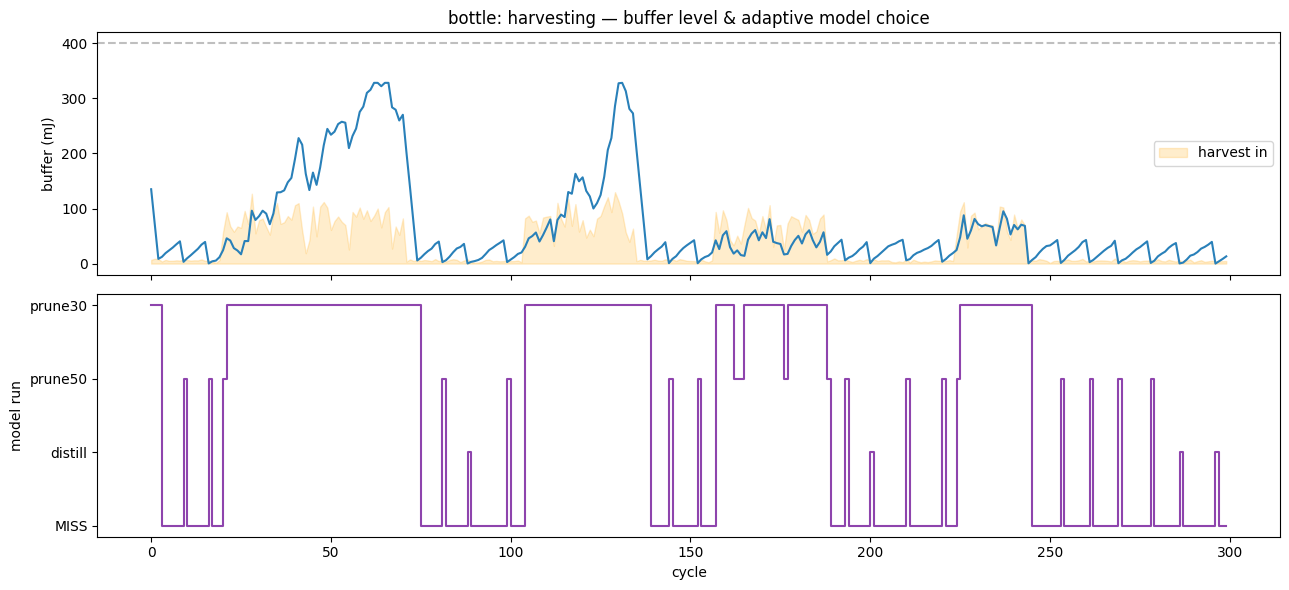

In [16]:
# Show buffer level + model choice over time for the adaptive policy
buf_trace, model_trace = [], []
buf = CAP_mJ * 0.5
L = LADDER[CAT]; ladder_sorted = sorted(L.items(), key=lambda kv: -kv[1]['energy_mJ'])
for t in range(300):  # first 300 cycles for readability
    buf = min(CAP_mJ, buf + harvest[t])
    chosen = None
    for name, m in ladder_sorted:
        if buf >= m['energy_mJ'] + IDLE_mJ:
            chosen = (name, m); break
    if chosen:
        buf -= chosen[1]['energy_mJ'] + IDLE_mJ
        model_trace.append({'prune30':3,'prune50':2,'distill':1}[chosen[0]])
    else:
        model_trace.append(0)  # miss
    buf_trace.append(buf)

fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
a1.plot(buf_trace, color='#2980b9'); a1.axhline(CAP_mJ, ls='--', color='gray', alpha=.5)
a1.fill_between(range(len(harvest[:300])), harvest[:300], alpha=.2, color='orange', label='harvest in')
a1.set_ylabel('buffer (mJ)'); a1.legend(); a1.set_title(f'{CAT}: harvesting — buffer level & adaptive model choice')
a2.plot(model_trace, drawstyle='steps-post', color='#8e44ad')
a2.set_yticks([0,1,2,3]); a2.set_yticklabels(['MISS','distill','prune50','prune30'])
a2.set_xlabel('cycle'); a2.set_ylabel('model run')
plt.tight_layout(); plt.show()

The upper plot shows the evolution of the supercapacitor energy buffer as intermittent energy is harvested. Periods of abundant harvested energy allow the buffer to recharge, while low-harvest periods progressively deplete it.

The lower plot shows the model selected by the adaptive policy at each cycle. When sufficient energy is available, the policy executes the most accurate (and most energy-demanding) model. As the buffer level decreases, the policy switches to progressively cheaper compressed models. If the stored energy is insufficient for any model, the cycle is marked as a missed inference. This visualization demonstrates how the adaptive strategy dynamically balances detection performance and energy availability under intermittent power conditions.

# Stage 4 — Report & Project Conclusion

## What Stage 4 demonstrates

Stage 4 evaluates whether runtime adaptation between compressed models provides a practical advantage under energy constraints. Contrary to the initial hypothesis, the experiments show that the adaptive policies do **not** outperform the best fixed strategy. Across the simulated battery scenarios, the static `prune50 L1` model consistently provides the strongest trade-off between accuracy and energy consumption, achieving both long operating lifetime and maintaining performance above the required accuracy floor.

This negative result is nevertheless important: it shows that, for this application and hardware platform, a carefully chosen compressed model can be sufficiently robust that additional runtime adaptation offers little practical benefit. In other words, model compression alone already solves most of the energy-efficiency problem.

## Grounded in real measurements

Every per-model cost is measured on the actual Arduino Nano 33 BLE Sense Rev 2 (latency → energy via datasheet power), and every accuracy is measured on-device (full MVTec test set (for *bottle* and *hazelnut* categories), full scoring protocol implemented in C). The policy decisions therefore rely on real hardware measurements rather than simulation alone.

## Honest limitations

* **Energy is estimated** from datasheet active current (6.3 mA @ 3.3 V), not measured with a current probe. The policy depends primarily on relative energy costs between models, which follow the measured latency ratios and are therefore robust to the absolute power estimate.
* **Battery and harvesting models are idealized** (linear energy accounting, no voltage sag, leakage, temperature effects, or conversion losses).
* **The adaptive policy is simulated off-device.** A complete firmware implementation with multiple models co-resident in flash and runtime switching would constitute a natural final integration step.
* **`distill` is nearly dominated** by `prune50 L1` (similar energy cost but consistently lower accuracy). As a result, the effective model ladder is largely reduced to `prune30 L1` and `prune50 L1`.

## The full project arc

1. **Stage 1** — compact autoencoder anomaly detector on MVTec (bottle = 0.9667 AUROC, hazelnut = 0.8854 AUROC at 64×64), with a fixed scoring protocol.
2. **Stage 2** — systematic compression (quantization, L1/Taylor pruning, distillation) and Pareto characterization.
3. **Stage 3** — real INT8 TFLite deployment on the Arduino: measured latency, memory, energy, and on-device AUROC matching software within 0.01.
4. **Stage 4** — evaluation of energy-aware adaptive inference strategies under battery and harvesting constraints.

The overall conclusion is that compression makes deployment on resource-constrained hardware possible, while adaptive inference is not universally beneficial. In this case, the compressed `prune50 L1` model already represents a highly effective operating point, demonstrating that the simplest strategy can sometimes be the most practical for embedded anomaly detection.
